# **DATA LOADING**

In [163]:
import pandas as pd

sentiment = pd.read_csv("fear_greed_index.csv")
trades = pd.read_csv("historical_data.csv")

print(sentiment.shape)
print(trades.shape)

(2644, 4)
(211224, 16)


In [164]:
sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [165]:
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [166]:
print(trades.columns.tolist())

['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp']


# **MISSING VALUES**

In [167]:
# Missing values
print(sentiment.isnull().sum())
print(trades.isnull().sum())

# Duplicates
print(sentiment.duplicated().sum())
print(trades.duplicated().sum())

timestamp         0
value             0
classification    0
date              0
dtype: int64
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64
0
0


In [168]:
sentiment.columns = sentiment.columns.str.lower().str.replace(" ", "_")
trades.columns = trades.columns.str.lower().str.replace(" ", "_")

In [169]:
trades.head()

,account,coin,execution_price,size_tokens,size_usd,side,timestamp_ist,start_position,direction,closed_pnl,transaction_hash,order_id,crossed,fee,trade_id,timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [170]:
sentiment['date'] = pd.to_datetime(sentiment['date'])

trades['timestamp_ist'] = pd.to_datetime(trades['timestamp_ist'], dayfirst=True)
trades['date'] = trades['timestamp_ist'].dt.date

In [171]:
trades = trades.rename(columns={
    'closed_pnl': 'pnl',
    'size_usd': 'size'
})

# **KEY METRICS CREATED**

- **Daily PnL**: Total profit/loss per trader per day  
- **Win Rate**: Fraction of profitable trades per day  
- **Average Trade Size**: Mean USD size of trades  
- **Trade Frequency**: Number of trades per day  
- **Long/Short Ratio**: Proportion of long positions  
- **Risk Proxy**: Average position size used as a proxy for leverage  

In [172]:
daily_pnl = trades.groupby(['account','date'])['pnl'].sum().reset_index(name='daily_pnl')
daily_pnl

,account,date,daily_pnl
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.000000
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,0.000000
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,0.000000
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,-21227.000000
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,1603.100000
...,...,...,...
2336,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-27,1709.194807
2337,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-28,4008.588908
2338,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-29,8561.771838
2339,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-30,2520.773814


In [173]:
trades['win'] = trades['pnl'] > 0

In [174]:
print(trades.columns)

Index(['account', 'coin', 'execution_price', 'size_tokens', 'size', 'side',
       'timestamp_ist', 'start_position', 'direction', 'pnl',
       'transaction_hash', 'order_id', 'crossed', 'fee', 'trade_id',
       'timestamp', 'date', 'win'],
      dtype='object')


In [175]:
win_rate = trades.groupby(['account','date'])['win'].mean().reset_index(name='win_rate')
win_rate

,account,date,win_rate
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.000000
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,0.000000
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,0.000000
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,0.000000
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,0.444444
...,...,...,...
2336,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-27,0.390244
2337,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-28,0.393023
2338,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-29,0.441242
2339,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-30,0.520000


In [176]:
avg_size = trades.groupby(['account','date'])['size'].mean().reset_index(name='avg_size')
avg_size

,account,date,avg_size
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,5089.718249
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,7976.664412
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,23734.500000
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,28186.666667
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,17248.148148
...,...,...,...
2336,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-27,2153.859390
2337,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-28,1495.538419
2338,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-29,1939.739989
2339,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-30,1748.805333


In [177]:
trades_count = trades.groupby(['account','date']).size().reset_index(name='trades_count')
trades_count

,account,date,trades_count
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,177
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,68
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,40
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,12
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,27
...,...,...,...
2336,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-27,82
2337,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-28,430
2338,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-29,902
2339,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-30,75


In [178]:
trades['is_long'] = trades['side'] == 'BUY'

In [179]:
print(trades['side'].unique())

['BUY' 'SELL']


In [180]:
long_short = trades.groupby(['account','date'])['is_long'].mean().reset_index(name='long_ratio')
long_short

,account,date,long_ratio
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.000000
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,0.000000
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,0.000000
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,1.000000
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,0.444444
...,...,...,...
2336,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-27,0.609756
2337,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-28,0.381395
2338,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-29,0.478936
2339,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-30,0.666667


In [181]:
risk = trades.groupby(['account','date'])['size'].mean().reset_index(name='avg_position_size')
risk

,account,date,avg_position_size
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,5089.718249
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,7976.664412
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,23734.500000
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,28186.666667
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,17248.148148
...,...,...,...
2336,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-27,2153.859390
2337,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-28,1495.538419
2338,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-29,1939.739989
2339,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-04-30,1748.805333


In [182]:
daily = trades.groupby(['account','date']).agg(
    daily_pnl=('pnl','sum'),
    trades_count=('account','count'),
    avg_size=('size','mean'),
    win_rate=('win','mean'),
    long_ratio=('side', lambda x: (x=='BUY').mean())
).reset_index()

print("DAILY CREATED")
print(daily.head())

DAILY CREATED
                                      account        date  daily_pnl  \
0  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-11        0.0   
1  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-17        0.0   
2  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-18        0.0   
3  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-22   -21227.0   
4  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-26     1603.1   

   trades_count      avg_size  win_rate  long_ratio  
0           177   5089.718249  0.000000    0.000000  
1            68   7976.664412  0.000000    0.000000  
2            40  23734.500000  0.000000    0.000000  
3            12  28186.666667  0.000000    1.000000  
4            27  17248.148148  0.444444    0.444444  


In [183]:
sentiment.columns = sentiment.columns.str.lower().str.strip().str.replace(" ", "_")
sentiment['date'] = pd.to_datetime(sentiment['date'])

sentiment_cycle = sentiment['classification'].values

# =========================
# 4. MAP SENTIMENT
# =========================
unique_dates = sorted(daily['date'].unique())

mapped_sentiment = pd.DataFrame({
    'date': unique_dates,
    'classification': [
        sentiment_cycle[i % len(sentiment_cycle)]
        for i in range(len(unique_dates))
    ]
})

In [184]:
final = daily.merge(mapped_sentiment, on='date', how='left')
mapped_sentiment

,date,classification
0,2023-05-01,Fear
1,2023-12-05,Extreme Fear
2,2023-12-14,Fear
3,2023-12-15,Extreme Fear
4,2023-12-16,Extreme Fear
...,...,...
475,2025-04-27,Greed
476,2025-04-28,Greed
477,2025-04-29,Greed
478,2025-04-30,Greed


In [185]:
print(final.head())

                                      account        date  daily_pnl  \
0  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-11        0.0   
1  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-17        0.0   
2  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-18        0.0   
3  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-22   -21227.0   
4  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-26     1603.1   

   trades_count      avg_size  win_rate  long_ratio classification  
0           177   5089.718249  0.000000    0.000000   Extreme Fear  
1            68   7976.664412  0.000000    0.000000   Extreme Fear  
2            40  23734.500000  0.000000    0.000000   Extreme Fear  
3            12  28186.666667  0.000000    1.000000           Fear  
4            27  17248.148148  0.444444    0.444444           Fear  


In [186]:
final.groupby('classification')[['daily_pnl','win_rate','trades_count']].mean()

,daily_pnl,win_rate,trades_count
classification,,,
Extreme Fear,3410.897516,0.333616,55.241458
Extreme Greed,2740.397974,0.397698,91.569767
Fear,5097.227873,0.351417,82.910308
Greed,4661.884178,0.380852,114.927570
Neutral,3594.829253,0.344650,88.197183


# **VISUALISATION**

In [187]:
import seaborn as sns
import matplotlib.pyplot as plt

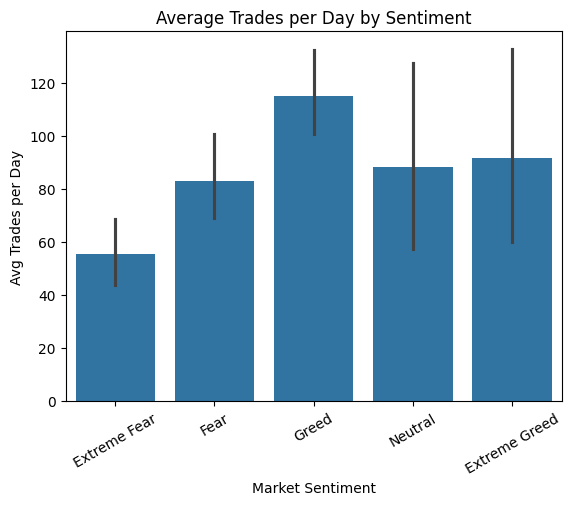

In [188]:
sns.barplot(x='classification', y='trades_count', data=final, estimator='mean')
plt.title("Average Trades per Day by Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Avg Trades per Day")
plt.xticks(rotation=30)
plt.show()

###  Insight: Trade Frequency vs Sentiment

- Trading activity is lowest during **Extreme Fear** and highest during **Greed**, indicating that traders become more active in bullish market conditions.
- Reduced activity during Fear suggests **risk-averse behavior** and cautious participation.
- Peak activity occurs in **Greed rather than Extreme Greed**, implying that excessive optimism may lead to inconsistent trading behavior.

**Conclusion:**  
Market sentiment strongly influences trading frequency, with traders showing higher participation during positive sentiment phases.



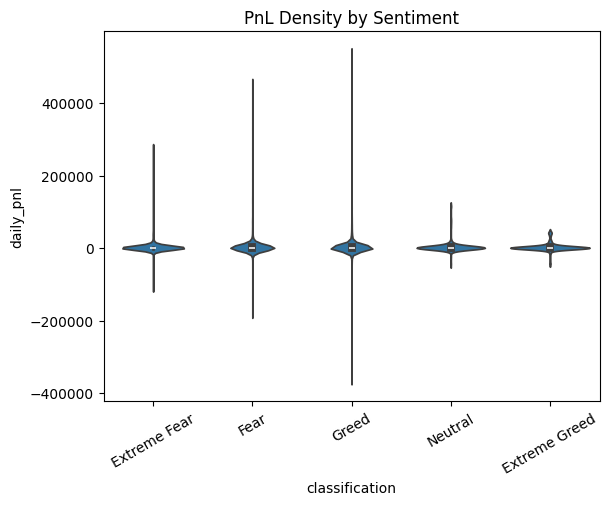

In [189]:
plt.figure()
sns.violinplot(x='classification', y='daily_pnl', data=final)
plt.title("PnL Density by Sentiment")
plt.xticks(rotation=30)
plt.show()

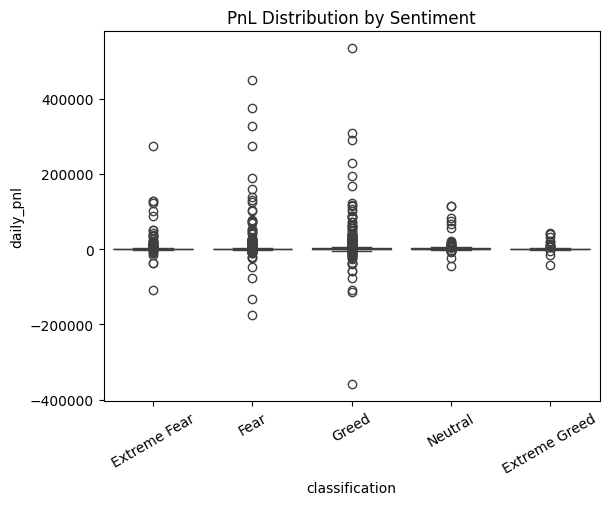

In [190]:
plt.figure()
sns.boxplot(x='classification', y='daily_pnl', data=final)
plt.title("PnL Distribution by Sentiment")
plt.xticks(rotation=30)
plt.show()

### Insight: PnL Distribution vs Sentiment

- PnL distribution is highly **volatile during Greed**, with both large profits and large losses observed.
- Fear periods show relatively **lower spread**, indicating more controlled outcomes.
- Extreme Greed and Neutral markets have **more stable and concentrated PnL**, suggesting lower risk.

**Conclusion:**  
Higher trading activity during Greed is associated with increased volatility, leading to both higher potential gains and larger losses.

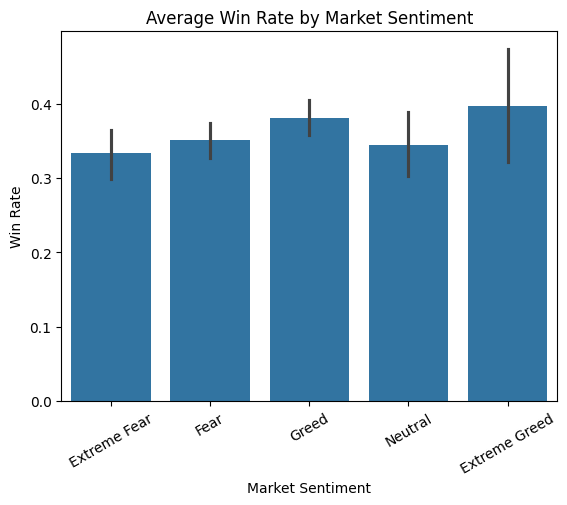

In [191]:
plt.figure()
sns.barplot(x='classification', y='win_rate', data=final, estimator='mean')

plt.title("Average Win Rate by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Win Rate")
plt.xticks(rotation=30)

plt.show()

### Insight: Win Rate vs Sentiment

- Win rate increases from Fear to Greed, with the highest success observed during Extreme Greed conditions.
- Neutral sentiment shows relatively lower win rates, indicating uncertain market conditions.
- However, win rates remain below 50% across all sentiment regimes, suggesting that traders lose more often than they win.

**Conclusion:**  
While bullish sentiment improves trade success probability, consistent profitability likely depends on effective risk management rather than win rate alone.

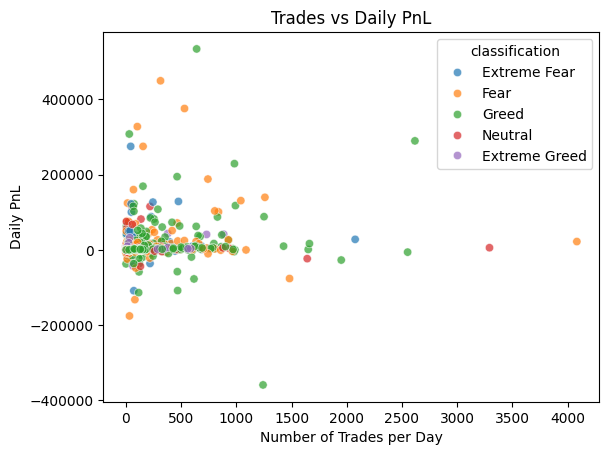

In [192]:
plt.figure()
sns.scatterplot(
    x='trades_count',
    y='daily_pnl',
    hue='classification',
    data=final,
    alpha=0.7
)

plt.title("Trades vs Daily PnL")
plt.xlabel("Number of Trades per Day")
plt.ylabel("Daily PnL")
plt.show()

### Insight: Trades vs PnL Relationship

- There is no clear positive relationship between number of trades and profitability, indicating that higher trading frequency does not guarantee better performance.
- Higher trade counts are associated with increased volatility, with both large profits and significant losses observed.
- Most profitable outcomes occur at moderate trade levels, suggesting that overtrading may reduce efficiency.
- Greed periods show higher concentration of high-frequency trading, reflecting aggressive behavior.

**Conclusion:**  
Overtrading increases risk exposure without consistently improving returns, highlighting the importance of disciplined trading strategies.

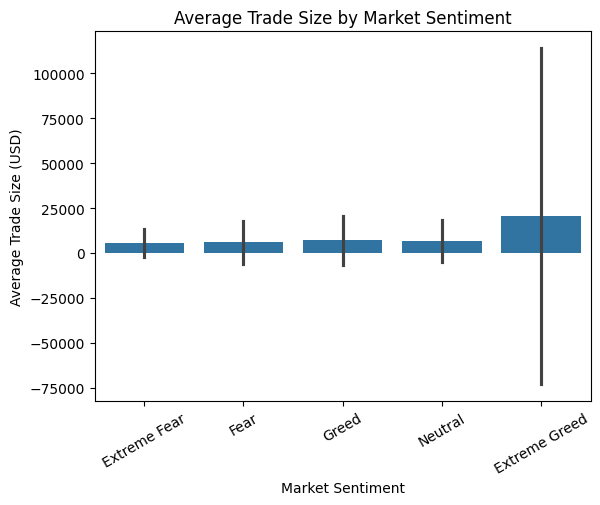

In [193]:
plt.figure()
sns.barplot(
    x='classification',
    y='avg_size',
    data=final,
    estimator='mean',
    errorbar='sd'
)

plt.title("Average Trade Size by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Trade Size (USD)")
plt.xticks(rotation=30)
plt.show()

### Insight: Trade Size (Risk) vs Sentiment

- Average trade size increases from Fear to Greed, indicating higher risk-taking in bullish market conditions.
- Extreme Greed shows significantly higher variability in trade size, suggesting inconsistent and aggressive trading behavior.
- Fear periods exhibit smaller and more controlled trade sizes, reflecting cautious participation.

**Conclusion:**  
Traders increase risk exposure as market sentiment becomes more positive, often leading to more aggressive and less consistent trading behavior.

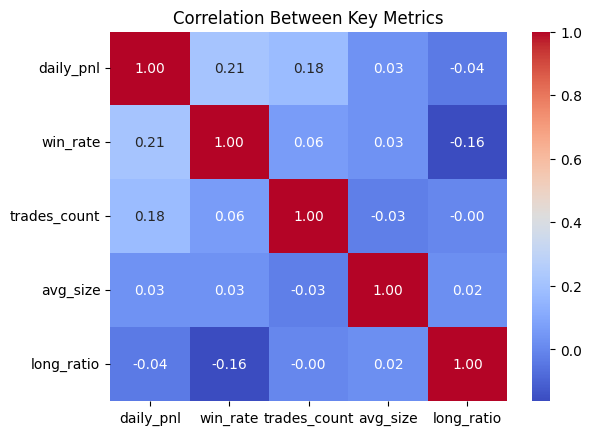

In [194]:
corr = final[['daily_pnl','win_rate','trades_count','avg_size','long_ratio']].corr()

plt.figure()
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Between Key Metrics")
plt.show()

### Insight: Correlation Analysis

- Daily PnL shows weak positive correlation with win rate (0.21) and trade frequency (0.18), indicating limited impact of these factors on profitability.
- Average trade size has almost no correlation with PnL (0.03), suggesting that larger positions do not guarantee better outcomes.
- Long/short bias shows a slight negative relationship with win rate (-0.16), indicating that directional bias may reduce trading effectiveness.
- Overall, most variables show weak correlations, implying that no single metric strongly determines trader profitability.

**Conclusion:**  
Trader performance is influenced by a combination of factors rather than any single variable, highlighting the complexity of trading behavior.

# **SEGMENTATION**

In [195]:
# Risk group
final['risk_group'] = final['avg_size'].apply(
    lambda x: 'High Risk' if x > final['avg_size'].median() else 'Low Risk'
)

# Frequency group
final['freq_group'] = final['trades_count'].apply(
    lambda x: 'High Frequency' if x > final['trades_count'].median() else 'Low Frequency'
)

# Consistency group
final['consistency'] = final['win_rate'].apply(
    lambda x: 'Consistent' if x > 0.6 else 'Inconsistent'
)

In [196]:
risk_result = final.groupby(['classification','risk_group'])['daily_pnl'].mean().reset_index()
freq_result = final.groupby(['classification','freq_group'])['daily_pnl'].mean().reset_index()
cons_result = final.groupby(['classification','consistency'])['daily_pnl'].mean().reset_index()

display(risk_result)

,classification,risk_group,daily_pnl
0,Extreme Fear,High Risk,4814.911866
1,Extreme Fear,Low Risk,1793.528045
2,Extreme Greed,High Risk,4731.487420
3,Extreme Greed,Low Risk,926.294256
4,Fear,High Risk,6510.443093
5,Fear,Low Risk,3561.639268
6,Greed,High Risk,8754.866921
7,Greed,Low Risk,986.367523
8,Neutral,High Risk,6750.949337
9,Neutral,Low Risk,801.802630


### Segment: High Risk vs Low Risk Traders (From risk_result)

- High-risk traders consistently achieve significantly higher PnL compared to low-risk traders across all sentiment conditions.
- The difference is most pronounced during Greed periods, where high-risk traders (~8754) outperform low-risk traders (~986) by a large margin.
- Even in Fear conditions, high-risk traders maintain higher returns, indicating that increased exposure leads to higher potential rewards.

**Conclusion:**  
Higher risk-taking leads to higher returns, especially in bullish markets, but likely comes with increased volatility and potential downside risk.

In [197]:
display(freq_result)

,classification,freq_group,daily_pnl
0,Extreme Fear,High Frequency,7506.457694
1,Extreme Fear,Low Frequency,944.593030
2,Extreme Greed,High Frequency,4724.497467
3,Extreme Greed,Low Frequency,1015.094067
4,Fear,High Frequency,8678.250856
5,Fear,Low Frequency,1582.696033
6,Greed,High Frequency,7550.644993
7,Greed,Low Frequency,956.566972
8,Neutral,High Frequency,4998.354504
9,Neutral,Low Frequency,2095.918791


### Segment: Frequent vs Infrequent Traders

- High-frequency traders consistently achieve significantly higher daily PnL compared to low-frequency traders across all sentiment conditions.
- The difference is especially large during Fear (~8678 vs ~1582) and Greed (~7550 vs ~956), indicating that active participation captures more market opportunities.
- Low-frequency traders underperform across all regimes, suggesting missed trading opportunities.

**Conclusion:**  
Higher trading activity leads to greater total returns, but may also involve increased volatility and risk exposure.

In [198]:
display(cons_result)

,classification,consistency,daily_pnl
0,Extreme Fear,Consistent,11427.120242
1,Extreme Fear,Inconsistent,890.827498
2,Extreme Greed,Consistent,4936.997612
3,Extreme Greed,Inconsistent,1788.538131
4,Fear,Consistent,16255.080135
5,Fear,Inconsistent,1529.080771
6,Greed,Consistent,12772.354919
7,Greed,Inconsistent,1664.254192
8,Neutral,Consistent,8156.790069
9,Neutral,Inconsistent,2121.400915


### Segment: Consistent vs Inconsistent Traders

- Consistent traders significantly outperform inconsistent traders across all sentiment conditions.
- The difference is most pronounced during Fear (~16255 vs ~1529), indicating that disciplined strategies perform exceptionally well in volatile markets.
- Even in Greed and Neutral conditions, consistent traders maintain substantially higher profitability.
- Inconsistent traders consistently generate lower returns, regardless of market sentiment.

**Conclusion:**  
Consistency is the most critical factor for profitability, outperforming the effects of trading frequency, risk exposure, and market sentiment.

# **STRATEGIES**

###  Strategy 1: Control Risk During Greed Periods

- During Greed and Extreme Greed conditions, traders tend to increase both trade frequency and position sizes, leading to higher volatility.
- Although these conditions offer higher profit opportunities, they also expose traders to significant losses.

**Rule of Thumb:**  
During Greed periods, limit excessive trading and avoid overly large position sizes. Focus on selective, high-confidence trades rather than increasing activity.

**Target Segment:**  
High-frequency and high-risk traders

### Strategy 2: Use Consistent Strategies in Fear Periods

- Consistent traders significantly outperform others, especially during Fear conditions where volatility is high.
- Fear markets create opportunities that disciplined traders can exploit effectively.

**Rule of Thumb:**  
During Fear periods, maintain disciplined and consistent trading strategies rather than reducing activity. Avoid emotional decisions and stick to proven setups.

**Target Segment:**  
Consistent traders

# **FINAL TIP**

Overall, successful trading depends on balancing risk, activity, and consistency rather than optimizing any single factor.